In [1]:
from IPython.core.interactiveshell import InteractiveShell as IS
IS.ast_node_interactivity = "all"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# plt.style.use("ggplot")
from config import *
from sklearn.linear_model import ElasticNet, Lasso, Ridge, lasso_path, enet_path
from joblib import Parallel, delayed
import datetime
import os
import seaborn as sns
plt.rcParams.update({
    'figure.dpi': 200,
    # 统一字体：SimHei支持中文，Times兼容英文负号（无冲突）
    'font.family': ['SimHei', 'Times New Roman'],
    'font.size': 20,
    'legend.fontsize': 18,
    'lines.linewidth': 5,
    'savefig.bbox': 'tight',
    # 核心：关闭Unicode负号，用ASCII减号（解决负号显示）
    'axes.unicode_minus': False
})

[(0.00784313725490196, 0.24313725490196078, 1.0),
 (1.0, 0.48627450980392156, 0.0),
 (0.10196078431372549, 0.788235294117647, 0.2196078431372549),
 (0.9098039215686274, 0.0, 0.043137254901960784),
 (0.5450980392156862, 0.16862745098039217, 0.8862745098039215),
 (0.6235294117647059, 0.2823529411764706, 0.0),
 (0.9450980392156862, 0.2980392156862745, 0.7568627450980392),
 (0.6392156862745098, 0.6392156862745098, 0.6392156862745098),
 (1.0, 0.7686274509803922, 0.0),
 (0.0, 0.8431372549019608, 1.0),
 (0.00784313725490196, 0.24313725490196078, 1.0),
 (1.0, 0.48627450980392156, 0.0),
 (0.10196078431372549, 0.788235294117647, 0.2196078431372549),
 (0.9098039215686274, 0.0, 0.043137254901960784),
 (0.5450980392156862, 0.16862745098039217, 0.8862745098039215),
 (0.6235294117647059, 0.2823529411764706, 0.0),
 (0.9450980392156862, 0.2980392156862745, 0.7568627450980392),
 (0.6392156862745098, 0.6392156862745098, 0.6392156862745098),
 (1.0, 0.7686274509803922, 0.0),
 (0.0, 0.8431372549019608, 1.0)]

[(0.7743368501529412, 0.19975926804705882, 0.2025345544352941),
 (0.8350272044352941, 0.31364431242352936, 0.25978315174117644),
 (0.8846434386941177, 0.41001709788235297, 0.32250654924705885),
 (0.9244088216823529, 0.49858955783529413, 0.38905901227058826),
 (0.951253794882353, 0.5787993895882353, 0.4594078057647059),
 (0.9673165156666667, 0.6574708288078431, 0.5381601507294118),
 (0.968203399, 0.7208441, 0.6122929913333334),
 (0.9563709270509804, 0.7751443261333334, 0.6864159483098039),
 (0.9306685963333333, 0.818876999654902, 0.7591463906980392),
 (0.8918168921215687, 0.8519732770431372, 0.829085274254902),
 (0.839351442772549, 0.861166825654902, 0.8944937634156863),
 (0.7867207013568628, 0.8448072103686275, 0.9398103849490196),
 (0.7289695795686274, 0.8174641357058824, 0.973187668372549),
 (0.6672529243333334, 0.7791764569999999, 0.992959213),
 (0.603162067917647, 0.7315274773529412, 0.9995652785372549),
 (0.5325682374117646, 0.6698005978823529, 0.9903932701176471),
 (0.46767809468235294, 0.6055912316235293, 0.9685462810941176),
 (0.4044212904941176, 0.5346434904470588, 0.9320019126352941),
 (0.34327752343529416, 0.45935363472941176, 0.8841219216235294),
 (0.28527277752941177, 0.38012942263529415, 0.8234685512470589)]

[(0.6196078431372549, 0.00392156862745098, 0.25882352941176473),
 (0.7295655517108804, 0.12587466359092656, 0.2848135332564398),
 (0.8376778162245291, 0.2467512495194156, 0.308881199538639),
 (0.9044213763936948, 0.34794309880815066, 0.28304498269896194),
 (0.9596309111880047, 0.44744329104190683, 0.2719723183391003),
 (0.9790080738177624, 0.5873894655901576, 0.3365628604382929),
 (0.9926951172625913, 0.7092656670511341, 0.40299884659746243),
 (0.9948481353325644, 0.8169165705497885, 0.4934256055363321),
 (0.9968473663975395, 0.9022683583237217, 0.5850826605151864),
 (0.9990003844675125, 0.9690119184928874, 0.697039600153787),
 (0.9750096116878124, 0.9900038446751249, 0.7100346020761246),
 (0.9211841599384853, 0.9684736639753941, 0.6260668973471745),
 (0.8293733179546331, 0.9312572087658594, 0.6108419838523644),
 (0.7023452518262209, 0.8795847750865053, 0.6366782006920415),
 (0.5697808535178779, 0.8272202998846598, 0.6445982314494426),
 (0.42122260668973477, 0.7690888119953864, 0.6467512495194156),
 (0.31203383314109956, 0.6626682045367166, 0.6876585928489043),
 (0.20007689350249905, 0.5377931564782776, 0.7393310265282584),
 (0.2806612841214917, 0.423760092272203, 0.6892733564013841),
 (0.3686274509803922, 0.30980392156862746, 0.6352941176470588)]

C:\Users\hyliu\AppData\Local\Temp\ipykernel_9904\3263226330.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_list = cm.get_cmap('viridis').colors


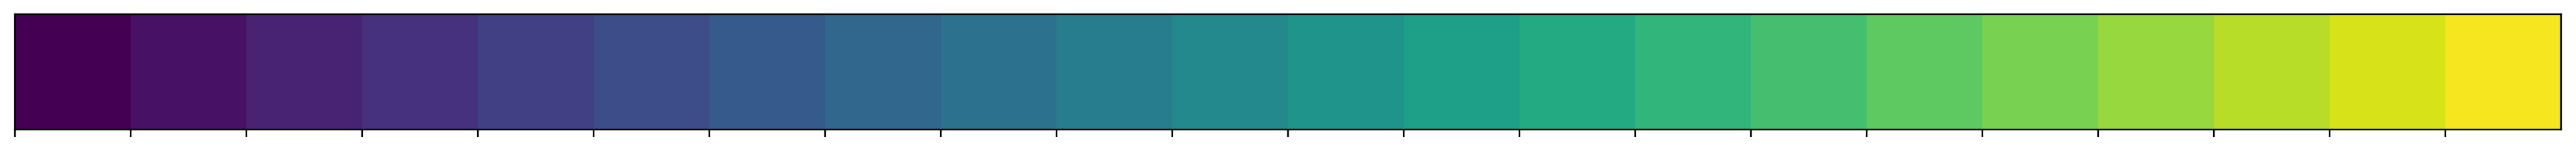

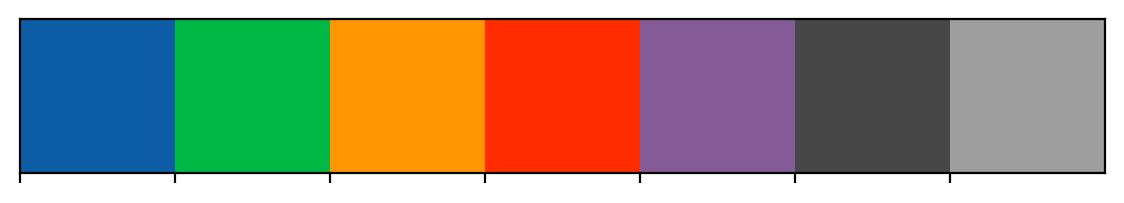

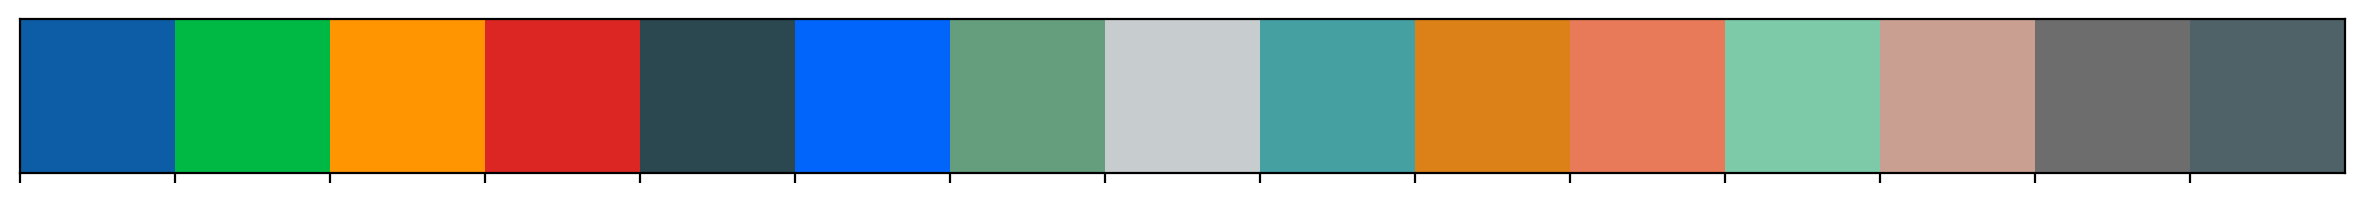

In [2]:
from cycler import cycler
from matplotlib import cm
palettes = ['colorblind', 'deep', 'muted', 'bright', 'pastel', 'dark']
sns.color_palette("bright", 20)

sns.color_palette("coolwarm_r", 20)

sns.color_palette(cm.Spectral(np.linspace(0, 1, 20)))


color_list = cm.get_cmap('viridis').colors
skip = len(color_list)//20
sns.palplot(color_list[::skip])

r_hex = '#dc2624'     # red,       RGB = 220,38,36
dt_hex = '#2b4750'    # dark teal, RGB = 43,71,80
tl_hex = '#45a0a2'    # teal,      RGB = 69,160,162
r1_hex = '#e87a59'    # red,       RGB = 232,122,89
tl1_hex = '#7dcaa9'   # teal,      RGB = 125,202,169
g_hex = '#649E7D'     # green,     RGB = 100,158,125
o_hex = '#dc8018'     # orange,    RGB = 220,128,24
tn_hex = '#C89F91'
# tan,       RGB = 200,159,145
g50_hex = '#6c6d6c'   # grey-50,   RGB = 108,109,108
bg_hex = '#4f6268'    # blue grey, RGB = 79,98,104
g25_hex = '#c7cccf'   # grey-25,   RGB = 199,204,207

color1 = ['#0C5DA5', '#00B945', '#FF9500', '#dc2624', '#2b4750','#0165fc','#649E7D', '#c7cccf', '#45a0a2',  '#dc8018','#e87a59',
         '#7dcaa9',  '#C89F91', 
         '#6c6d6c', '#4f6268']
sns.palplot(['#0C5DA5', '#00B945', '#FF9500', '#FF2C00', '#845B97', '#474747', '#9e9e9e'])
sns.palplot(color1)

plt.rcParams['axes.prop_cycle'] = cycler('color', color1)

# 读取数据

In [3]:
df = pd.read_csv(f"./{prefix}clean_data.csv", parse_dates=[date_col])
df.head()

,datetime,instrument,行业,1M,3M,5M,10M,换手率相对波动率,市净率,市现率,...,营业利润增速,营业收入增速,累计振动升降指标技术,股东权益比率,资金现金回收率,交易量波动率,成交量,振幅,换手率,市值
0,2011-01-31,000001.SZ,银行,0.009416,0.108600,0.088512,-0.021343,-0.584515,-1.150260,-0.226998,...,3.158336,-0.507100,-2.972825,-1.645895,0.283258,-0.010465,3.012026,-1.283349,-0.876369,2.120147
1,2011-01-31,000002.SZ,房地产,0.064951,-0.039216,-0.001225,-0.084559,-0.621015,-0.951068,-0.511976,...,-0.499833,-1.341502,-2.972825,-1.305793,-0.775457,0.414102,3.012026,-0.484444,-0.632041,2.120147
2,2011-01-31,000004.SZ,计算机,-0.041455,-0.106909,-0.020364,-0.411636,-0.436859,2.680992,0.457127,...,2.474313,2.537240,-0.277429,0.590042,0.446986,2.636784,-0.769777,-1.470545,-0.720860,-1.142613
3,2011-01-31,000005.SZ,公用事业,-0.047059,-0.091765,-0.091765,-0.091765,-0.801889,-0.042845,1.256209,...,-0.929440,-1.522111,-0.217577,-0.136835,-0.343615,-0.053438,0.143500,-0.991249,-1.089254,0.012108
4,2011-01-31,000006.SZ,房地产,0.085873,-0.023546,-0.199446,-0.432133,1.325544,-0.965183,0.409521,...,3.158336,2.537240,-2.719129,-1.270994,-0.421182,-0.316737,2.622975,-0.143325,1.548874,0.515990


In [4]:
df[date_col].min()
df[date_col].max()
df.shape

Timestamp('2011-01-31 00:00:00')

Timestamp('2021-04-30 00:00:00')

(363427, 25)

## 参数

In [5]:
test_start_year = 2020
train_year_span = None
valid_year_span = 1
test_year_span = 2

## 数据集划分

In [6]:
date_lst = [df[date_col][df[stock_col]==i] for i in df[stock_col].unique()]
_tmp = Parallel(n_jobs=1)(delayed(get_idxs)(date, test_start_year, train_year_span, valid_year_span, test_year_span) for date in date_lst)
train_idxs, val_idxs, test_idxs = zip(*_tmp)
train_idxs, val_idxs, test_idxs = np.concatenate(train_idxs), np.concatenate(val_idxs), np.concatenate(test_idxs)

In [7]:
X_train = df.iloc[train_idxs][factors_lst]
y_train = df.iloc[train_idxs][[f"{target}"]]
train_idx_cols = pd.MultiIndex.from_frame(df.iloc[train_idxs][date_stock_lst], names=date_stock_lst)
train_results = pd.DataFrame({}, index=train_idx_cols, dtype=float)

X_valid = df.iloc[val_idxs][factors_lst]
y_valid = df.iloc[val_idxs][[f"{target}"]]
valid_idx_cols = pd.MultiIndex.from_frame(df.iloc[val_idxs][date_stock_lst], names=date_stock_lst)
valid_results = pd.DataFrame({}, index=valid_idx_cols, dtype=float)

X_test = df.iloc[test_idxs][factors_lst]
y_test = df.iloc[test_idxs][[f"{target}"]]
test_idx_cols = pd.MultiIndex.from_frame(df.iloc[test_idxs][date_stock_lst], names=date_stock_lst)
test_results = pd.DataFrame({}, index=test_idx_cols, dtype=float)

In [8]:
# pred_score = df.iloc[test_idxs][["date", "stock_id"]]
# pred_score.columns = ["datetime", "instrument"]
# pred_score = pred_score.set_index(["datetime", "instrument"])

# 路径

## Lasso path

In [9]:
alphas_lasso, coefs_lasso, _  = lasso_path(X_train, y_train, #eps=eps,
                                           alphas = np.arange(1e-3, 7e-3, 1e-3))
predictors_idxs = np.arange(len(factors_lst))[np.abs(coefs_lasso.squeeze()).sum(axis=1)>0.0001]
predictors = [factors_lst[i] for i in predictors_idxs]
coefs_lasso_select = coefs_lasso[:, predictors_idxs]

coefs_lasso_select_df = pd.DataFrame(np.squeeze(coefs_lasso_select, axis=0), index=predictors, columns=alphas_lasso).T

<Axes: >

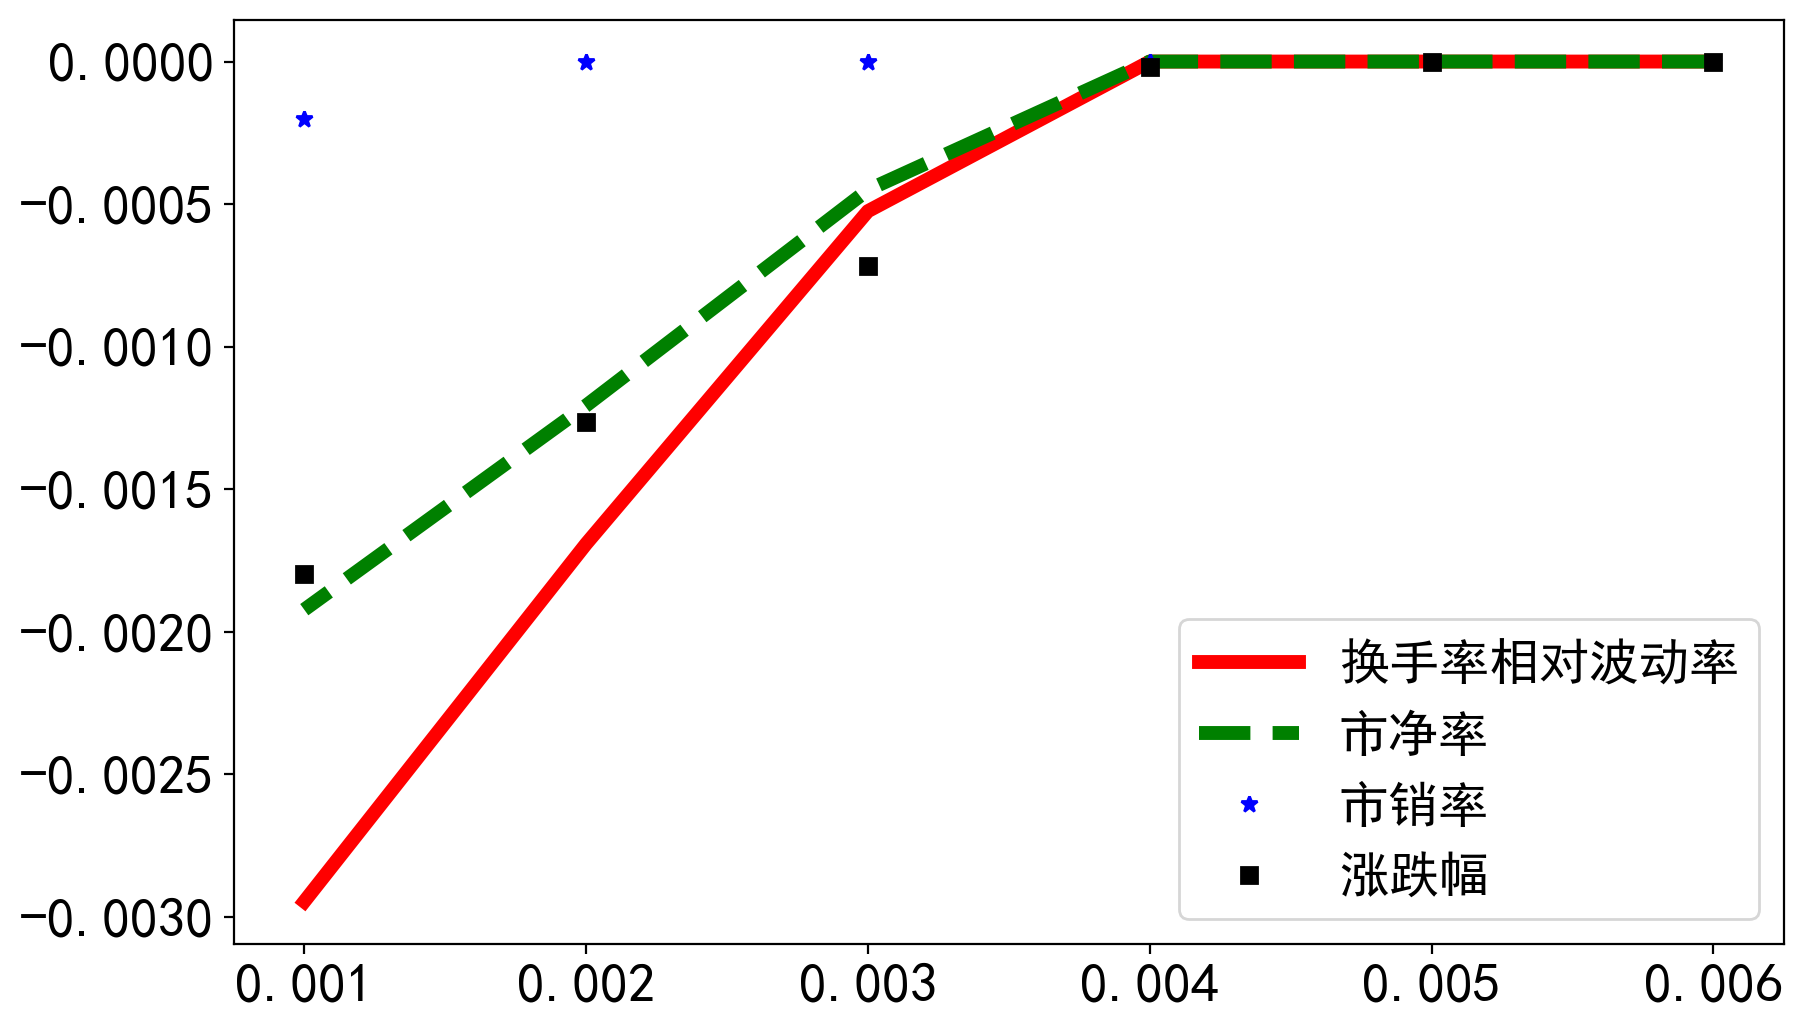

In [15]:
coefs_lasso_select_df.iloc[:, :4].plot(legend=True, figsize=(10, 6), 
                                       style=['r-', 'g--', 'b*', "ks"]); 
plt.savefig(generateFilePath("lasso_path"), bbox_inches="tight")

In [16]:
np.sum((coefs_lasso_select[0,:]==0), axis=1)

array([3, 3, 5, 2, 4, 5, 5, 4, 5, 2, 3])

## ridge path

In [19]:
# alphas = np.logspace(-3, 5, 100)
alphas = np.logspace(-3, 6, 100)
ridge_res = {}

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    _ = ridge.fit(X_train,y_train) 
    ridge_res[alpha] = ridge.coef_.flatten() 

df_ridge_res = pd.DataFrame.from_dict(ridge_res).T 
df_ridge_res.columns = factors_lst

<Axes: >

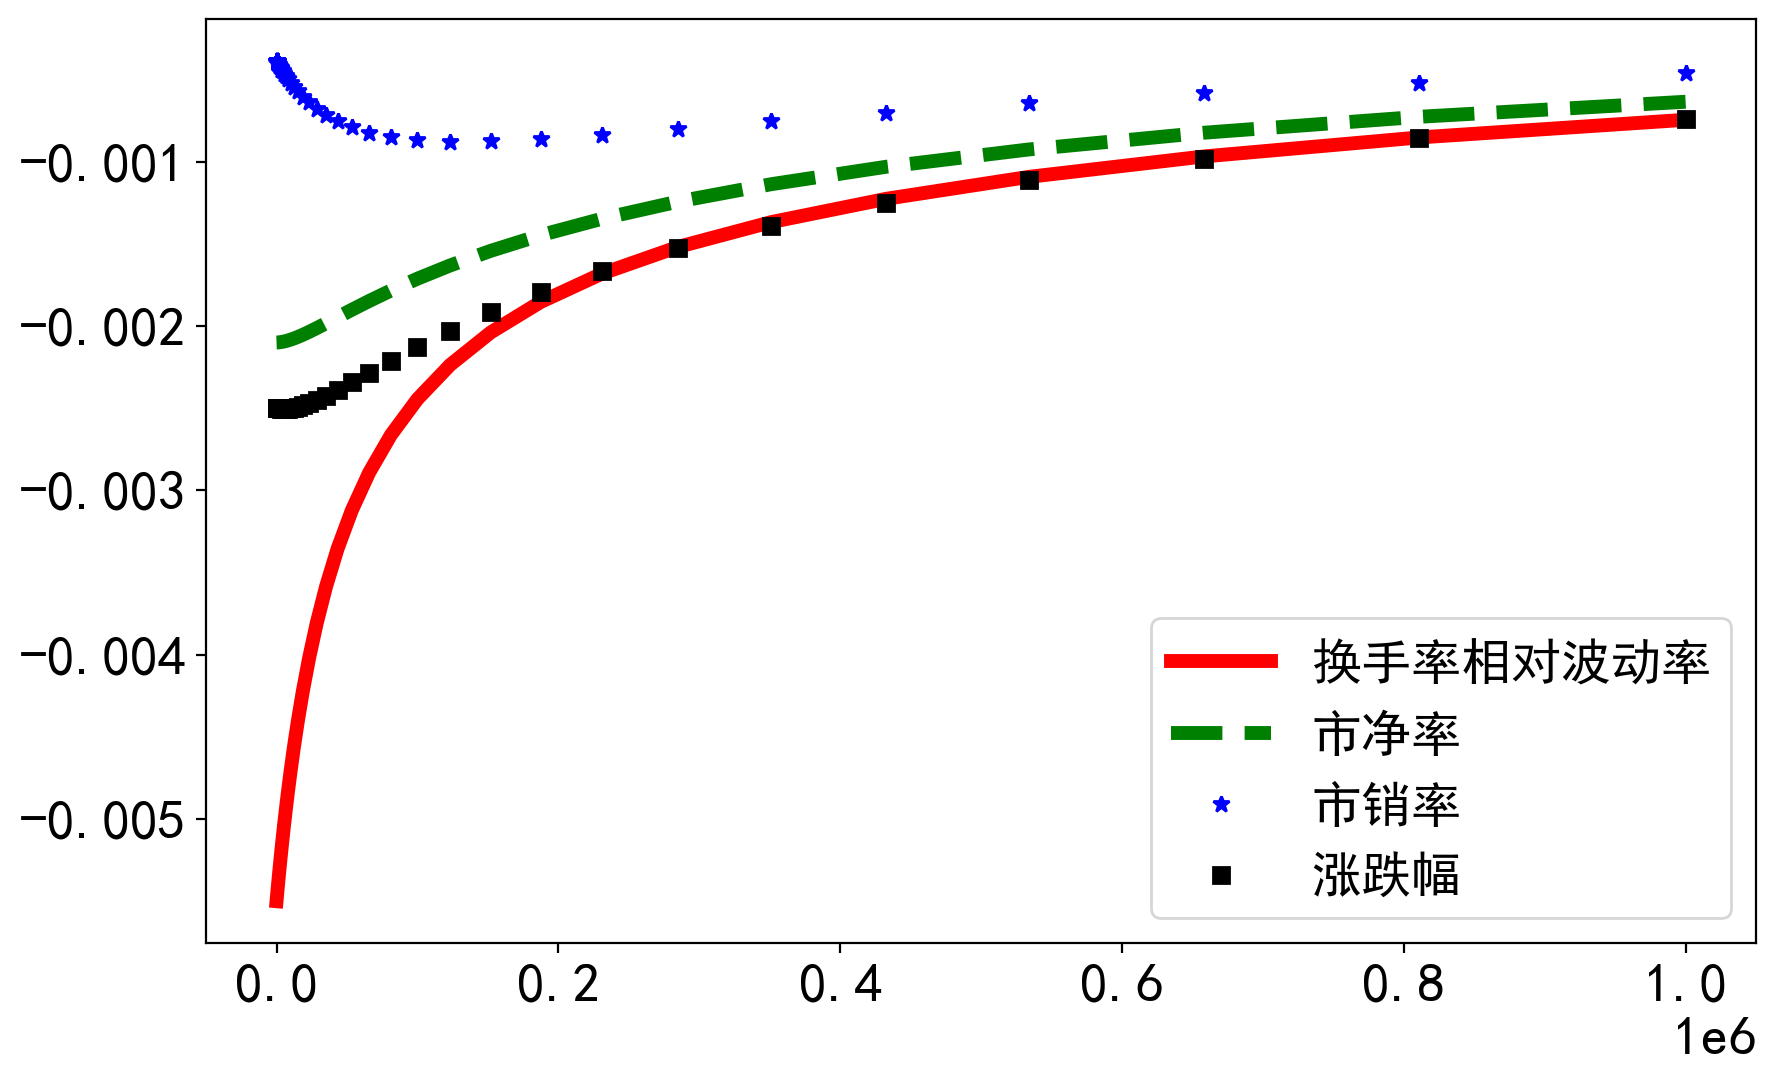

In [20]:
df_ridge_res[predictors].iloc[:, :4].plot(legend=True, figsize=(10, 6),
                             style=['r-', 'g--', 'b*', "ks"]); 
plt.savefig(generateFilePath("ridge_path"), bbox_inches="tight")

## elasticnet path

In [22]:
eps = 5e-3
alphas_ela, coefs_ela, _  = enet_path(X_train, y_train, eps=eps,
                                          l1_ratio = 0.01,
                                          alphas = np.arange(0.01, 0.3, 0.01))

coefs_ela_df = pd.DataFrame(np.squeeze(coefs_ela, axis=0), index=factors_lst, columns=alphas_ela).T

<Axes: >

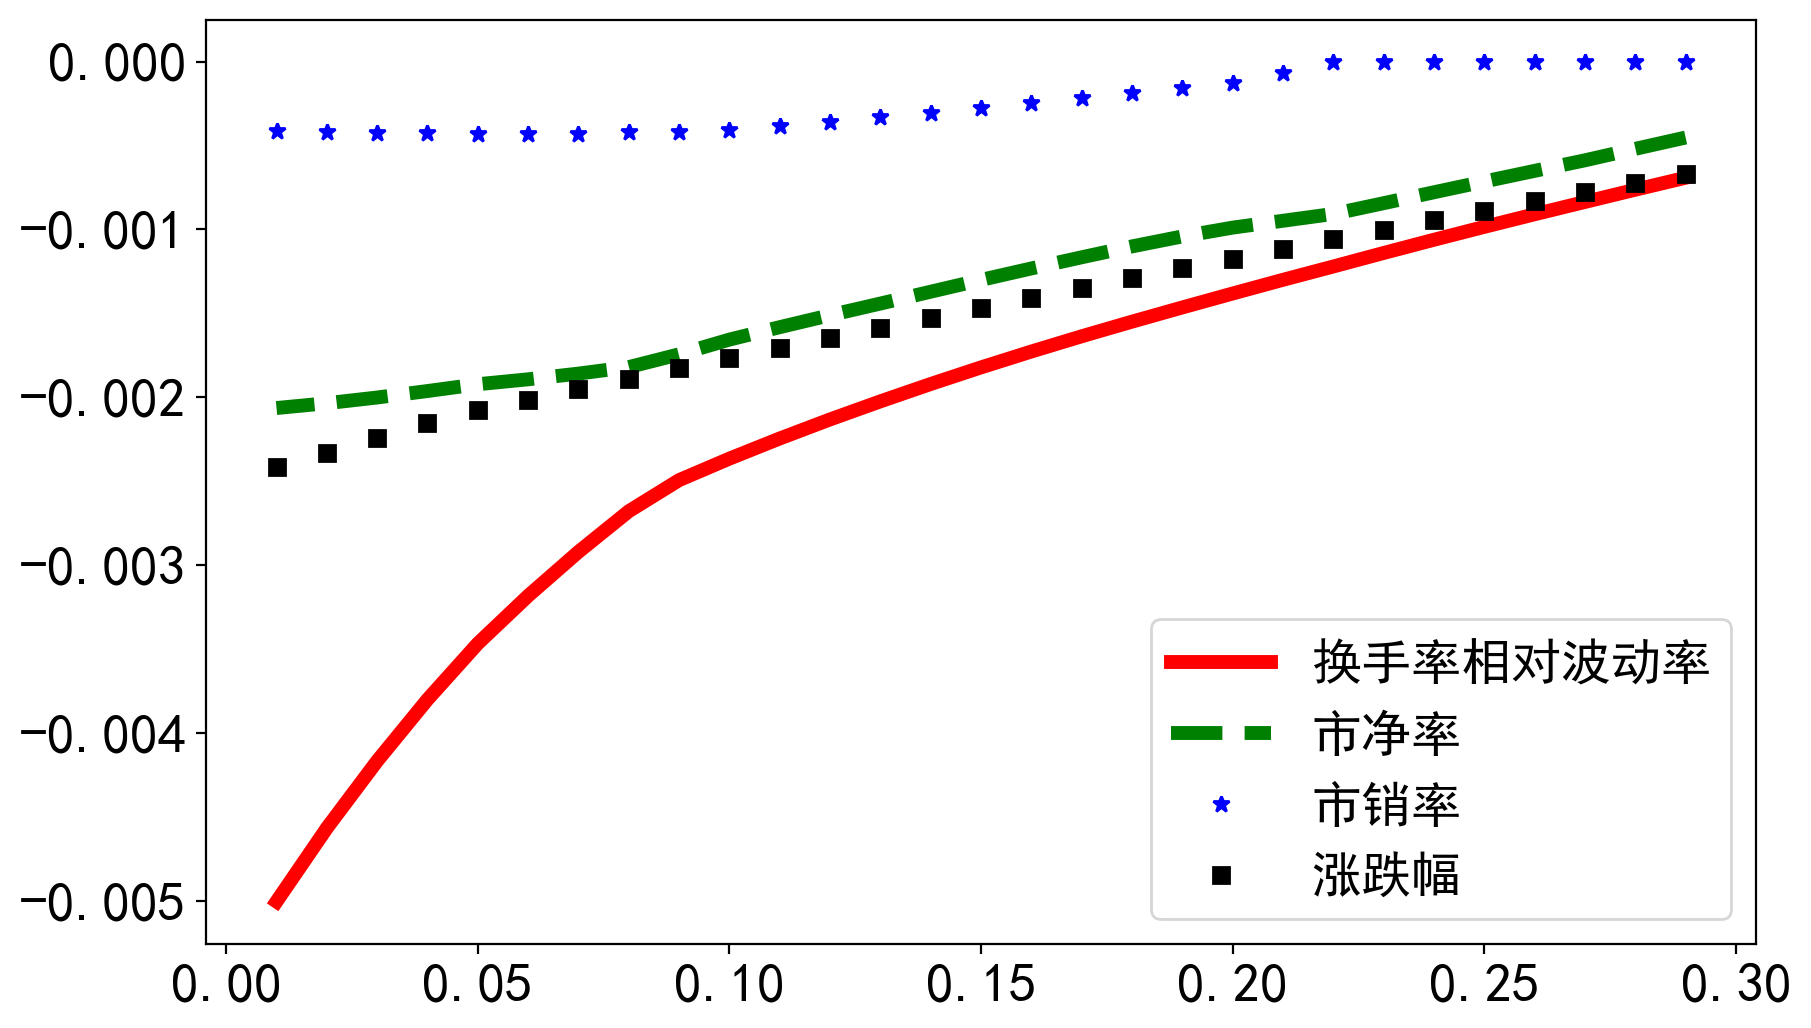

In [23]:
coefs_ela_df[predictors].iloc[:, :4].plot(legend=True, figsize=(10, 6),
                                          style=['r-', 'g--', 'b*', "ks"]); 
plt.savefig(generateFilePath("enet_path0.01"), bbox_inches="tight")

In [24]:
eps = 5e-3
alphas_ela, coefs_ela, _  = enet_path(X_train, y_train, eps=eps,
                                          l1_ratio = 0.05,
                                          alphas = np.arange(0.01, 0.3, 0.01))

coefs_ela_df = pd.DataFrame(np.squeeze(coefs_ela, axis=0), index=factors_lst, columns=alphas_ela).T

<Axes: >

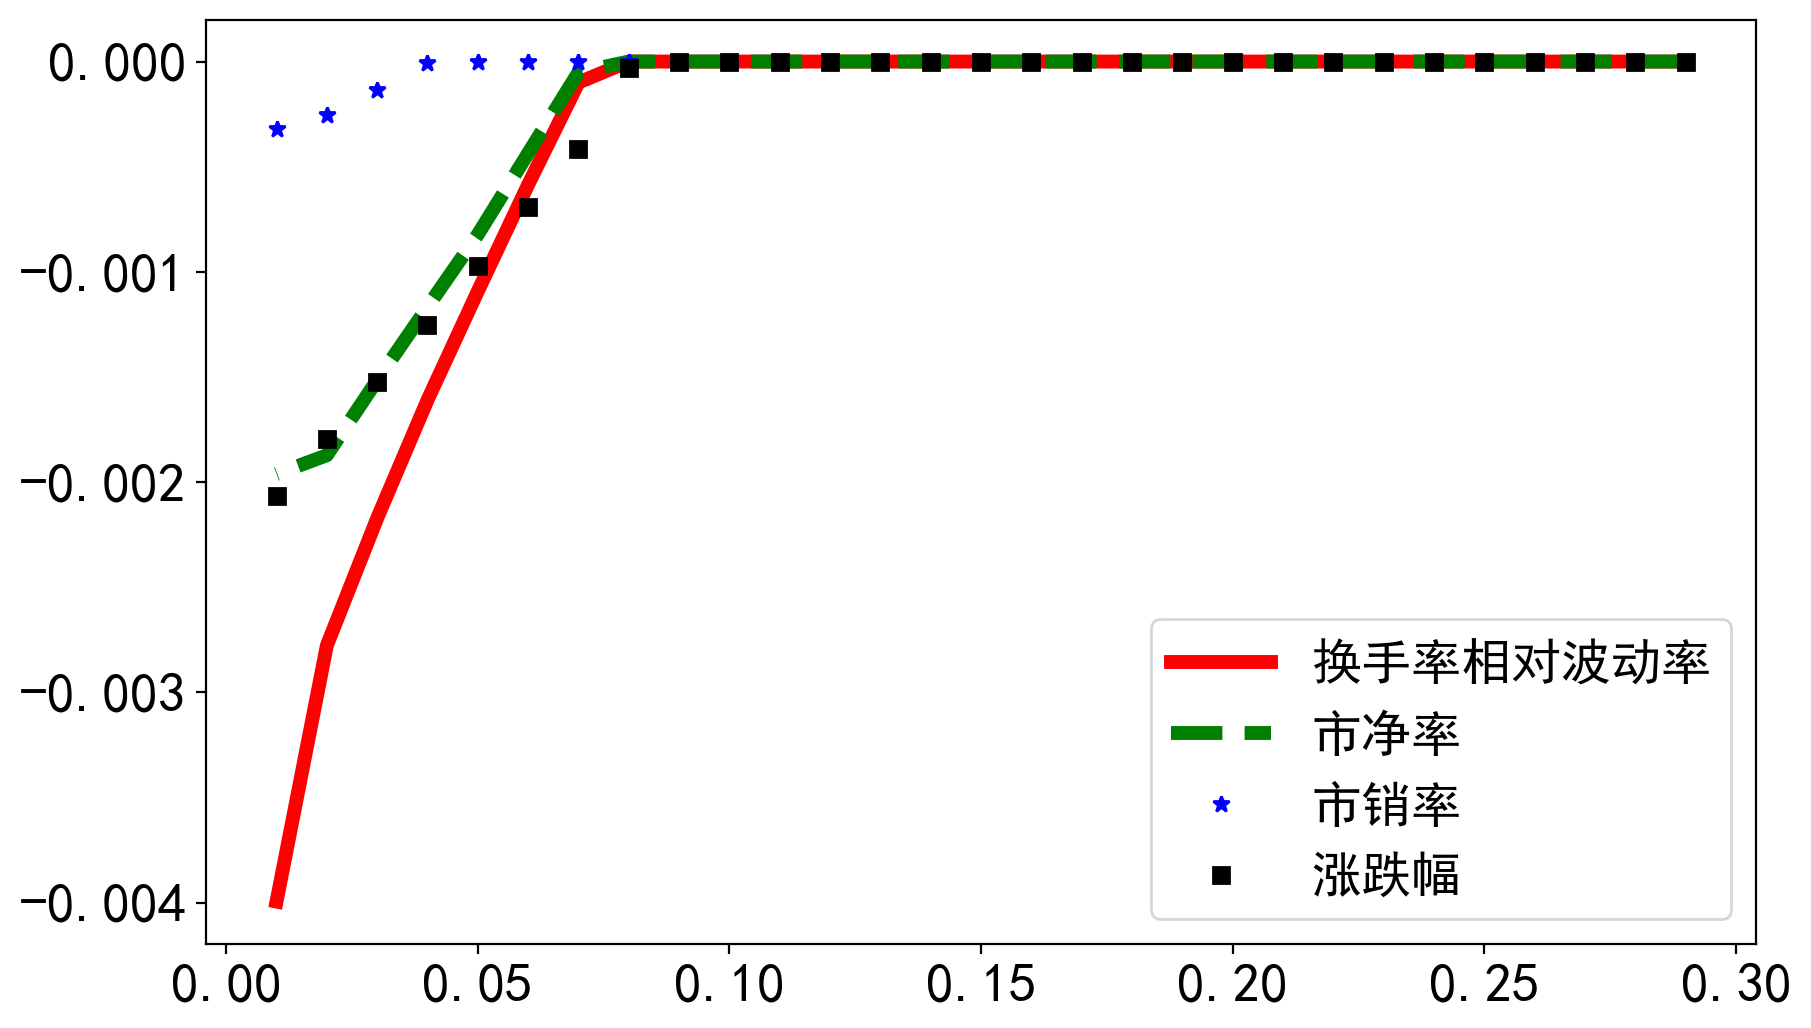

In [25]:
coefs_ela_df[predictors].iloc[:, :4].plot(legend=True, figsize=(10, 6),
                                          style=['r-', 'g--', 'b*', "ks"]); 
plt.savefig(generateFilePath("enet_path0.05"), bbox_inches="tight")

In [26]:
eps = 5e-3
alphas_ela, coefs_ela, _  = enet_path(X_train, y_train, eps=eps,
                                          l1_ratio = 0.2,
                                          alphas = np.arange(0.01, 0.3, 0.01))

coefs_ela_df = pd.DataFrame(np.squeeze(coefs_ela, axis=0), index=factors_lst, columns=alphas_ela).T

<Axes: >

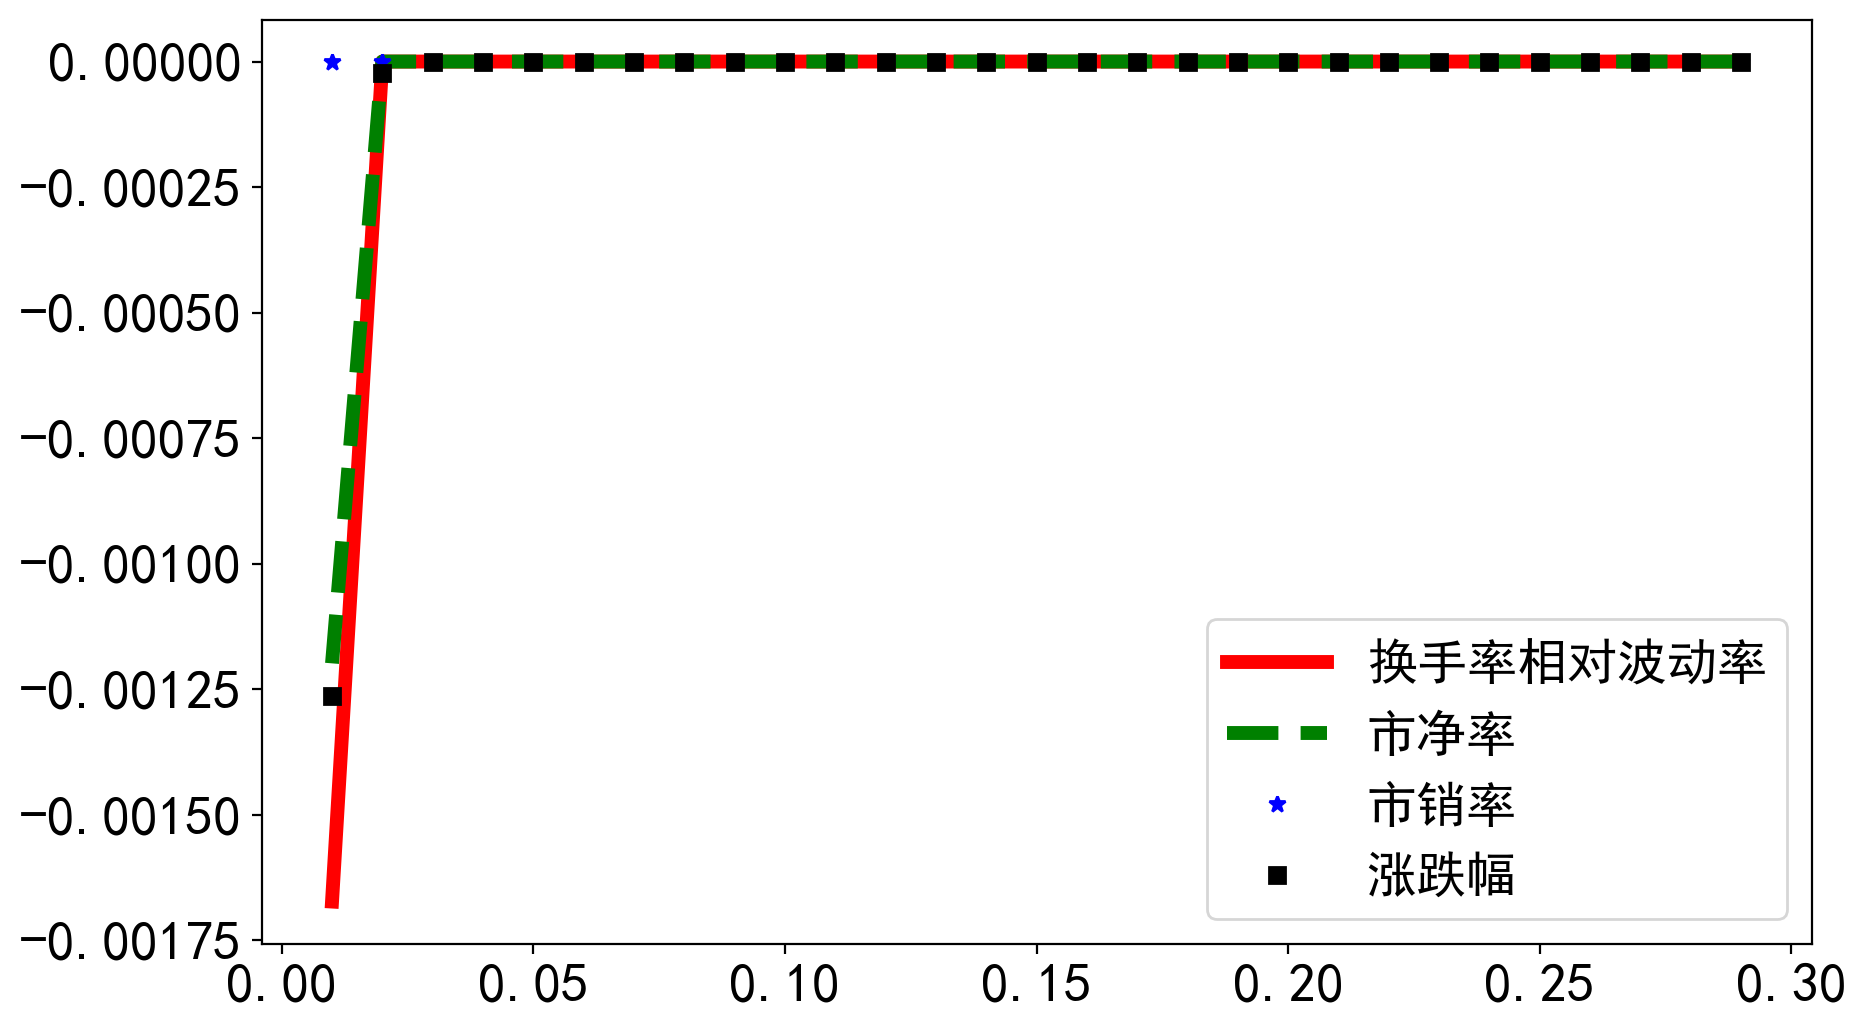

In [27]:
coefs_ela_df[predictors].iloc[:, :4].plot(legend=True, figsize=(10, 6),
                                          style=['r-', 'g--', 'b*', "ks"]); 
plt.savefig(generateFilePath("enet_path0.2"), bbox_inches="tight")